# Exploratory data analysis

In this project, we build an end-to-end machine learning pipeline to predict the total number of units sold by store WI_2 one day ahead, given historical daily sales and calendar information. This exploratory data analysis supports data preparation before model training.

We begin with preliminary data exploration, followed by univariate data analysis and then bivariate data analysis, which focuses on relationships between calendar features and daily sales. Additional time-series analyses are included after these sections.

## 1. Preliminary data exploration

Inspect the first few rows to get an intuition for the calendar and sales data.

In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import kruskal, spearmanr

pd.set_option("display.max_columns", 100)
plt.style.use("seaborn-v0_8-whitegrid")

candidate_roots = [Path.cwd(), Path.cwd() / "ts", Path.cwd().parent]
PROJECT_ROOT = next(
    root for root in candidate_roots
    if (root / "data" / "m5-forecasting-accuracy").exists()
)
DATA_DIR = PROJECT_ROOT / "data" / "m5-forecasting-accuracy"
STORE_ID = "WI_2"

calendar_raw = pd.read_csv(
    DATA_DIR / "calendar.csv",
    dtype={
        "weekday": "string",
        "event_name_1": "string",
        "event_type_1": "string",
        "event_name_2": "string",
        "event_type_2": "string",
    },
    keep_default_na=True,
    na_values=["NA", ""],
)

calendar_raw.head()

,date,wm_yr_wk,weekday,wday,month,year,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
0,2011-01-29,11101,Saturday,1,1,2011,<NA>,<NA>,<NA>,<NA>,0,0,0
1,2011-01-30,11101,Sunday,2,1,2011,<NA>,<NA>,<NA>,<NA>,0,0,0
2,2011-01-31,11101,Monday,3,1,2011,<NA>,<NA>,<NA>,<NA>,0,0,0
3,2011-02-01,11101,Tuesday,4,2,2011,<NA>,<NA>,<NA>,<NA>,1,1,0
4,2011-02-02,11101,Wednesday,5,2,2011,<NA>,<NA>,<NA>,<NA>,1,0,1


In [ ]:
sales_header = pd.read_csv(DATA_DIR / "sales_train_evaluation.csv", nrows=0)
day_columns = [column for column in sales_header.columns if column.startswith("d_")]
identifier_columns = ["item_id", "dept_id", "cat_id", "store_id", "state_id"]
sales_dtypes = {column: "string" for column in identifier_columns}
sales_dtypes.update({column: "int64" for column in day_columns})

sales_raw = pd.read_csv(
    DATA_DIR / "sales_train_evaluation.csv",
    usecols=identifier_columns + day_columns,
    dtype=sales_dtypes,
    low_memory=False,
)

sales_raw.head()

,item_id,dept_id,cat_id,store_id,state_id,d_1,d_2,d_3,d_4,d_5,d_6,d_7,d_8,d_9,d_10,d_11,d_12,d_13,d_14,d_15,d_16,d_17,d_18,d_19,d_20,d_21,d_22,d_23,d_24,d_25,d_26,d_27,d_28,d_29,d_30,d_31,d_32,d_33,d_34,d_35,d_36,d_37,d_38,d_39,d_40,d_41,d_42,d_43,d_44,d_45,...,d_1892,d_1893,d_1894,d_1895,d_1896,d_1897,d_1898,d_1899,d_1900,d_1901,d_1902,d_1903,d_1904,d_1905,d_1906,d_1907,d_1908,d_1909,d_1910,d_1911,d_1912,d_1913,d_1914,d_1915,d_1916,d_1917,d_1918,d_1919,d_1920,d_1921,d_1922,d_1923,d_1924,d_1925,d_1926,d_1927,d_1928,d_1929,d_1930,d_1931,d_1932,d_1933,d_1934,d_1935,d_1936,d_1937,d_1938,d_1939,d_1940,d_1941
0,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,1,0,4,2,3,0,1,2,0,0,0,1,1,3,0,1,1,1,3,0,1,1,0,0,0,2,0,3,5,0,0,1,1,0,2,1,2,2,1,0,2,4,0,0,0,0,3,3,0,1
1,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,2,1,1,0,0,0,0,0
2,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,1,0,0,0,0,0,1,2,2,1,2,1,1,1,0,1,1,1,0,0,1,1,0,2,1,0,0,0,0,2,1,3,0,0,1,0,1,0,2,0,0,0,2,3,0,1
3,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,0,0,2,0,1,0,0,...,2,1,3,1,0,2,5,4,2,0,3,0,1,0,5,4,1,0,1,3,7,2,0,0,1,2,4,1,6,4,0,0,0,2,2,4,2,1,1,1,1,1,0,4,0,1,3,0,2,6
4,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,4,0,1,0,1,0,1,1,2,0,1,1,2,1,1,0,1,1,2,2,2,4,1,0,2,3,1,0,3,2,3,1,1,3,2,3,2,2,2,2,0,0,0,2,1,0,0,2,1,0


In [3]:
print("Calendar dimensions:", calendar_raw.shape)
print("Calendar column names:", calendar_raw.columns.tolist())
print("Sales dimensions:", sales_raw.shape)
print("Sales column names:", sales_raw.columns.tolist())

Calendar dimensions: (1969, 13)
Calendar column names: ['date', 'wm_yr_wk', 'weekday', 'wday', 'month', 'year', 'event_name_1', 'event_type_1', 'event_name_2', 'event_type_2', 'snap_CA', 'snap_TX', 'snap_WI']
Sales dimensions: (30490, 1946)
Sales column names: ['item_id', 'dept_id', 'cat_id', 'store_id', 'state_id', 'd_1', 'd_2', 'd_3', 'd_4', 'd_5', 'd_6', 'd_7', 'd_8', 'd_9', 'd_10', 'd_11', 'd_12', 'd_13', 'd_14', 'd_15', 'd_16', 'd_17', 'd_18', 'd_19', 'd_20', 'd_21', 'd_22', 'd_23', 'd_24', 'd_25', 'd_26', 'd_27', 'd_28', 'd_29', 'd_30', 'd_31', 'd_32', 'd_33', 'd_34', 'd_35', 'd_36', 'd_37', 'd_38', 'd_39', 'd_40', 'd_41', 'd_42', 'd_43', 'd_44', 'd_45', 'd_46', 'd_47', 'd_48', 'd_49', 'd_50', 'd_51', 'd_52', 'd_53', 'd_54', 'd_55', 'd_56', 'd_57', 'd_58', 'd_59', 'd_60', 'd_61', 'd_62', 'd_63', 'd_64', 'd_65', 'd_66', 'd_67', 'd_68', 'd_69', 'd_70', 'd_71', 'd_72', 'd_73', 'd_74', 'd_75', 'd_76', 'd_77', 'd_78', 'd_79', 'd_80', 'd_81', 'd_82', 'd_83', 'd_84', 'd_85', 'd_86', 'd_

In [ ]:
calendar_dates = pd.to_datetime(calendar_raw["date"])
print("Calendar date range:", calendar_dates.min().date(), "to", calendar_dates.max().date())

The calendar contains 1,969 rows and 13 columns. The sales table contains 30,490 item-store rows with 1,941 historical day columns. The calendar runs from 2011-01-29 to 2016-06-19, while the selected store is WI_2. The calendar contains 28 more dates than the sales history because it includes future dates used for the forecasting horizon.

In [4]:
def build_daily_store_series(calendar_frame, sales_frame, day_columns, store_id):
    """Align item-level sales to one daily series for a selected store."""
    calendar = calendar_frame.copy()
    calendar.insert(
        0,
        "d",
        [f"d_{number}" for number in range(1, len(calendar) + 1)],
    )

    store_sales = sales_frame.loc[sales_frame["store_id"] == store_id]
    daily_sales = store_sales[day_columns].sum(axis=0).rename("sales")
    daily_sales = daily_sales.rename_axis("d").reset_index()

    daily_series = (
        daily_sales
        .merge(calendar, on="d", how="left", validate="one_to_one")
        .sort_values("date")
        .reset_index(drop=True)
    )
    return daily_series, store_sales

df, store_sales = build_daily_store_series(
    calendar_raw,
    sales_raw,
    day_columns,
    STORE_ID,
)
df.head()

,d,sales,date,wm_yr_wk,weekday,wday,month,year,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
0,d_1,2256,2011-01-29,11101,Saturday,1,1,2011,<NA>,<NA>,<NA>,<NA>,0,0,0
1,d_2,1922,2011-01-30,11101,Sunday,2,1,2011,<NA>,<NA>,<NA>,<NA>,0,0,0
2,d_3,2018,2011-01-31,11101,Monday,3,1,2011,<NA>,<NA>,<NA>,<NA>,0,0,0
3,d_4,2522,2011-02-01,11101,Tuesday,4,2,2011,<NA>,<NA>,<NA>,<NA>,1,1,0
4,d_5,1175,2011-02-02,11101,Wednesday,5,2,2011,<NA>,<NA>,<NA>,<NA>,1,0,1


### 1.1 Preliminary data exploration by columns

The columns are categorised as follows.

In [5]:
identifiers = ["d"]
numeric_integer_features = ["snap_WI"]
numeric_float_features = []
categorical_nominal_features = [
    "weekday",
    "event_name_1",
    "event_type_1",
    "event_name_2",
    "event_type_2",
]
datetime_features = ["date", "wday", "month", "year"]
target = ["sales"]

category_to_column_dict = {
    "identifier": identifiers,
    "numeric_integer": numeric_integer_features,
    "numeric_float": numeric_float_features,
    "categorical_nominal": categorical_nominal_features,
    "datetime": datetime_features,
    "target": target,
}
category_to_column_dict

{'identifier': ['d'],
 'numeric_integer': ['snap_WI'],
 'numeric_float': [],
 'categorical_nominal': ['weekday',
  'event_name_1',
  'event_type_1',
  'event_name_2',
  'event_type_2'],
 'datetime': ['date', 'wday', 'month', 'year'],
 'target': ['sales']}

Information regarding each column is summarised below.

In [6]:
column_to_category_dict = {
    column: category
    for category, columns in category_to_column_dict.items()
    for column in columns
}

columns_summary = pd.DataFrame({
    "column": df.columns,
    "category": [
        column_to_category_dict.get(column, "uncategorized")
        for column in df.columns
    ],
    "dtype": df.dtypes.astype(str).values,
    "null_count": df.isna().sum().values,
})

columns_summary.sort_values("category")

,column,category,dtype,null_count
4,weekday,categorical_nominal,string,0
8,event_name_1,categorical_nominal,string,1783
9,event_type_1,categorical_nominal,string,1783
10,event_name_2,categorical_nominal,string,1937
11,event_type_2,categorical_nominal,string,1937
2,date,datetime,str,0
5,wday,datetime,int64,0
6,month,datetime,int64,0
7,year,datetime,int64,0
0,d,identifier,str,0


Inspecting the columns summary informs the following decisions:

Correcting structural errors: the calendar file does not contain the canonical d identifier, so d is derived from the validated calendar row order before sales are aligned.

Handling datetime values: the date column will be converted from object to datetime so the daily sales records have an explicit time axis. The wday, month, and year fields are treated as datetime-derived features.

Handling event values: event fields are null when no event is recorded. These expected categorical nulls will be represented as No event. Event name and type fields are sparse because most dates have no recorded event.

Dropping identifiers: the day key is used to align sales with the calendar and is not needed as a model feature.

In [7]:
def convert_date_to_datetime(frame):
    frame = frame.copy()
    frame["date"] = pd.to_datetime(frame["date"], errors="coerce")
    return frame

df = convert_date_to_datetime(df)

# verify the converted date values
df["date"].dtype, df["date"].is_monotonic_increasing

(dtype('<M8[us]'), True)

### 1.2 Preliminary data exploration by rows

Inspect duplicate entries based on the date identifier.

In [8]:
df["date"].duplicated().sum()

# show examples when duplicates exist
df[df["date"].duplicated(keep=False)].sort_values("date").head()

,d,sales,date,wm_yr_wk,weekday,wday,month,year,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI


In [9]:
duplicate_entries_differences = (
    df[df["date"].duplicated(keep=False)]
    .drop(columns=["d"])
    .groupby("date")
    .nunique(dropna=False)
    .gt(1)
    .sum()
)

duplicate_entries_differences[duplicate_entries_differences > 0]

Series([], dtype: int64)

Inspecting duplicated entries informs the following decision:

No duplicate dates are present in the aggregated daily target, so no rows are removed.

In [10]:
def drop_irrelevant_columns(frame, dropped_irrelevant_columns):
    return frame.drop(columns=dropped_irrelevant_columns)

df = drop_irrelevant_columns(df, ["d"])

df["date"].duplicated().sum(), df.columns

(np.int64(0),
 Index(['sales', 'date', 'wm_yr_wk', 'weekday', 'wday', 'month', 'year',
        'event_name_1', 'event_type_1', 'event_name_2', 'event_type_2',
        'snap_CA', 'snap_TX', 'snap_WI'],
       dtype='str'))

## 2. Univariate data analysis

### 2.1 Univariate data analysis for numeric features and the numeric target variable

Inspecting summary statistics for numeric features and daily sales.

In [11]:
df[numeric_integer_features + numeric_float_features + target].describe().T

,count,mean,std,min,25%,50%,75%,max
snap_WI,1941.0,0.329727,0.470235,0.0,0.0,0.0,1.0,1.0
sales,1941.0,3450.792375,1304.984661,0.0,2376.0,3522.0,4403.0,7852.0


Inspecting barplots and histograms for numeric features and daily sales.

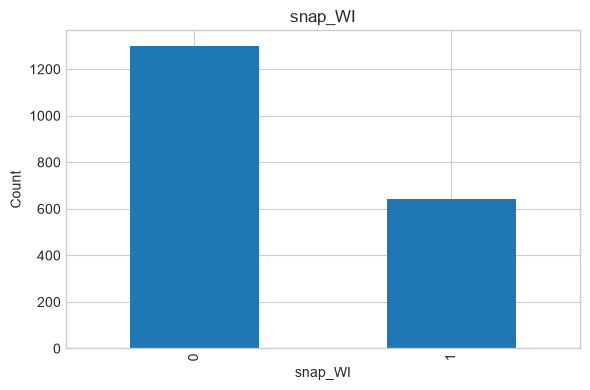

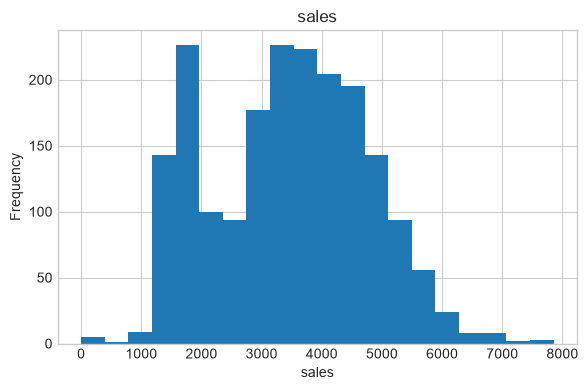

In [12]:
for column in numeric_integer_features:
    counts = df[column].value_counts().sort_index()
    axis = counts.plot(kind="bar", figsize=(6, 4))
    axis.bar_label(axis.containers[0], fmt="%d", padding=3)
    axis.margins(y=0.15)
    axis.set_title(column)
    axis.set_xlabel(column)
    axis.set_ylabel("Count")
    plt.tight_layout()
    plt.show()

for column in numeric_float_features + target:
    plt.figure(figsize=(6, 4))
    plt.hist(df[column].dropna(), bins=20)
    plt.title(column)
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

The daily sales mean is 3,450.79 units and the standard deviation is 1,304.98. Sales range from 0 to 7,852 units. There are two zero-sales days, no negative sales days, and no missing sales days.

In [18]:
# retain the day key needed to count item rows with nonzero sales
analysis_df = df.copy()
analysis_df["d"] = [f"d_{number}" for number in range(1, len(analysis_df) + 1)]
analysis_df = analysis_df.set_index("date")
series = analysis_df["sales"].astype(float).asfreq("D")

### Daily sales with rolling summaries

In [ ]:
# plot daily sales and rolling summaries
fig, ax = plt.subplots(figsize=(15, 4))
series.plot(ax=ax, label="Daily sales", linewidth=0.8)
series.rolling(7).mean().plot(
    ax=ax,
    label="7-day rolling mean",
)
series.rolling(28).mean().plot(
    ax=ax,
    label="28-day rolling mean",
)
ax.set_title(f"{STORE_ID} daily sales")
ax.set_ylabel("Units sold")
ax.legend()
plt.tight_layout()
plt.show()

### IQR-based high-sales outlier analysis

In [19]:
q1, q3 = analysis_df["sales"].quantile([0.25, 0.75])
upper_outlier_cutoff = q3 + 1.5 * (q3 - q1)
outlier_days = analysis_df.loc[
    analysis_df["sales"] > upper_outlier_cutoff,
    ["d", "sales", "weekday", "event_name_1"],
]
print(f"IQR upper cutoff: {upper_outlier_cutoff:,.0f}")
print(f"Number of IQR high days: {len(outlier_days)}")
outlier_days.sort_values("sales", ascending=False).head(10)

IQR upper cutoff: 7,444
Number of IQR high days: 3


,d,sales,weekday,event_name_1
date,,,,
2016-04-09,d_1898,7852,Saturday,No event
2016-05-14,d_1933,7704,Saturday,No event
2016-05-15,d_1934,7586,Sunday,No event


The IQR upper cutoff is 7,444 units, producing three high-sales days. These observations are retained for review because genuine demand peaks may be important to forecast.

### Low-sales-day investigation

Review low-sales days against calendar events and the number of item rows with nonzero sales.

In [20]:
lower_outlier_cutoff = q1 - 1.5 * (q3 - q1)
low_sales_days = analysis_df.loc[
    analysis_df["sales"] < lower_outlier_cutoff,
].copy()
low_sales_review = analysis_df.nsmallest(10, "sales").copy()
low_sales_review["date"] = low_sales_review.index
low_sales_review["nonzero_item_rows"] = low_sales_review["d"].map(
    lambda day: (store_sales[day] > 0).sum()
)
print(f"IQR lower cutoff: {lower_outlier_cutoff:,.0f}")
print(f"Number of IQR low days: {len(low_sales_days)}")
low_sales_review[[
    "date", "d", "sales", "weekday",
    "event_name_1", "event_type_1", "snap_WI",
    "nonzero_item_rows",
]]

IQR lower cutoff: -664
Number of IQR low days: 0


,date,d,sales,weekday,event_name_1,event_type_1,snap_WI,nonzero_item_rows
date,,,,,,,,
2013-12-25,2013-12-25,d_1062,0,Wednesday,Christmas,National,0,0
2014-12-25,2014-12-25,d_1427,0,Thursday,Christmas,National,0,0
2015-12-25,2015-12-25,d_1792,1,Friday,Christmas,National,0,1
2011-12-25,2011-12-25,d_331,3,Sunday,Christmas,National,0,3
2012-12-25,2012-12-25,d_697,3,Tuesday,Christmas,National,0,3
2011-11-24,2011-11-24,d_300,682,Thursday,Thanksgiving,National,0,239
2011-04-24,2011-04-24,d_86,949,Sunday,OrthodoxEaster,Religious,0,327
2011-05-29,2011-05-29,d_121,1126,Sunday,No event,No event,0,387
2011-04-19,2011-04-19,d_81,1135,Tuesday,No event,No event,0,390


The lower IQR cutoff is -665 units, so no days meet the formal lower-outlier rule. The five lowest days occur on Christmas Day from 2011 to 2015 and contain 0, 0, 1, 3, and 3 units, with 0, 0, 1, 3, and 3 nonzero item rows. These values are consistent with a store-closure pattern recorded by the Christmas national event. The remaining low values are historical demand observations, so the low-sales days are retained rather than imputed or removed.

### 2.2 Univariate data analysis for categorical features

Inspecting unique values for each categorical feature.

In [13]:
for column in categorical_nominal_features:
    print(column, ":", df[column].unique())

weekday : <StringArray>
['Saturday', 'Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']
Length: 7, dtype: string
event_name_1 : <StringArray>
[                 <NA>,           'SuperBowl',       'ValentinesDay',
       'PresidentsDay',           'LentStart',           'LentWeek2',
       'StPatricksDay',           'Purim End',      'OrthodoxEaster',
          'Pesach End',       'Cinco De Mayo',        'Mother's day',
         'MemorialDay',      'NBAFinalsStart',        'NBAFinalsEnd',
        'Father's day',     'IndependenceDay',      'Ramadan starts',
         'Eid al-Fitr',            'LaborDay',         'ColumbusDay',
           'Halloween',           'EidAlAdha',         'VeteransDay',
        'Thanksgiving',           'Christmas',        'Chanukah End',
             'NewYear',   'OrthodoxChristmas', 'MartinLutherKingDay',
              'Easter']
Length: 31, dtype: string
event_type_1 : <StringArray>
[<NA>, 'Sporting', 'Cultural', 'National', 'Religious']
Length: 

Inspecting unique values for the categorical features informs the following decision:

The weekday and SNAP fields contain consistent categorical levels. Event fields are sparse because most days have no recorded event; these expected missing values represent non-event days and are relabelled as No event.

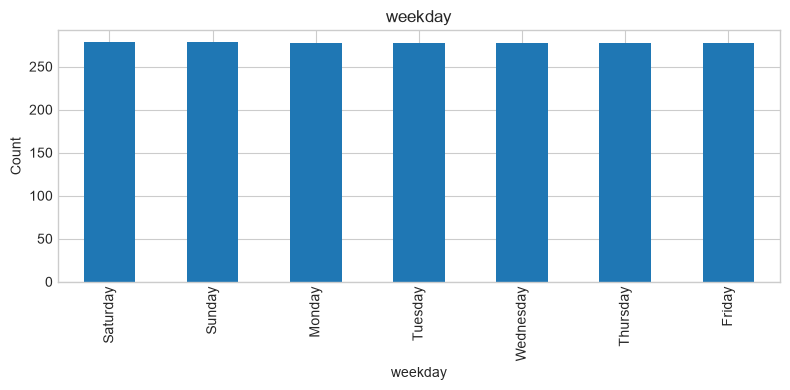

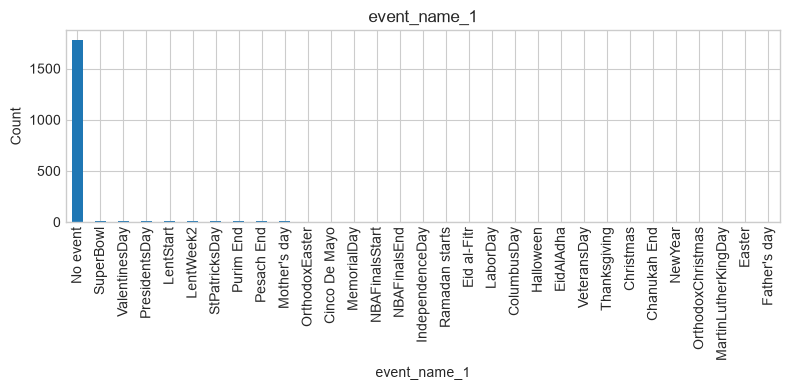

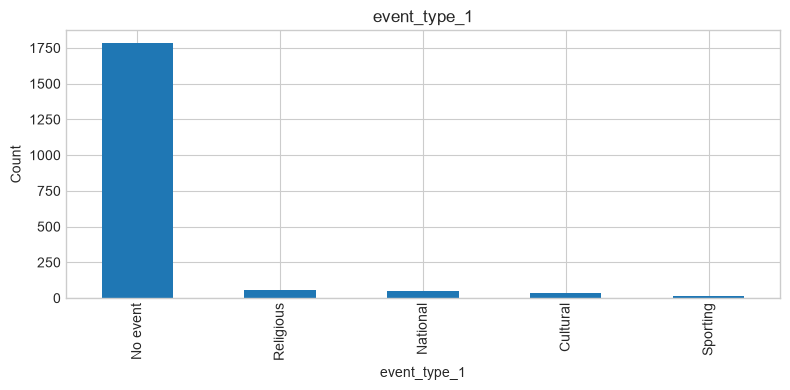

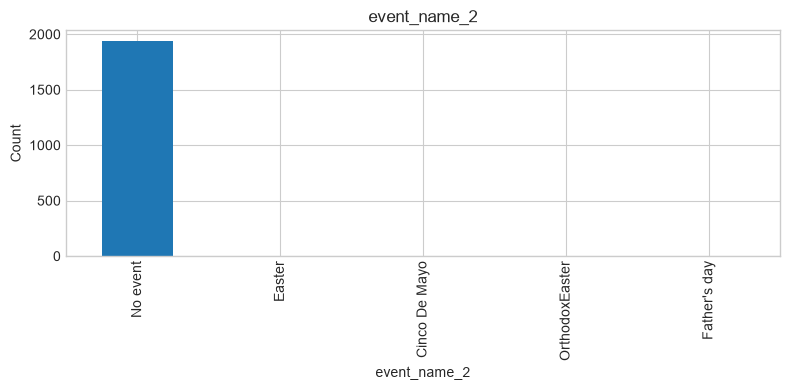

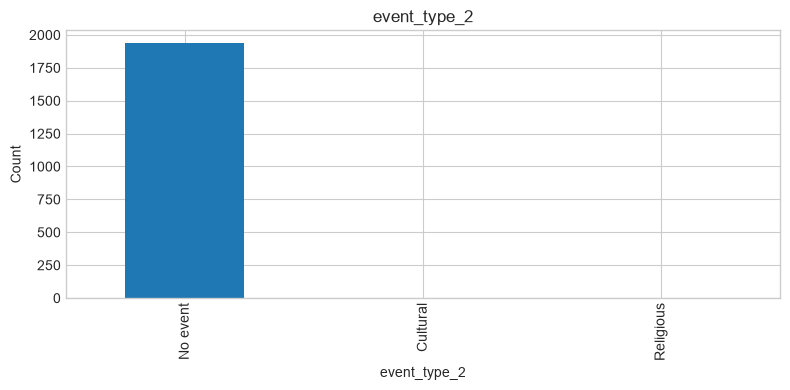

In [14]:
def fill_missing_event_labels(frame, categorical_features):
    frame = frame.copy()
    for column in categorical_features:
        frame[column] = frame[column].fillna("No event")
    return frame

df = fill_missing_event_labels(df, categorical_nominal_features)

for column in categorical_nominal_features:
    counts = df[column].fillna("Missing").value_counts()
    axis = counts.plot(kind="bar", figsize=(8, 4))
    axis.bar_label(axis.containers[0], fmt="%d", padding=3)
    axis.margins(y=0.15)
    axis.set_title(column)
    axis.set_xlabel(column)
    axis.set_ylabel("Count")
    plt.tight_layout()
    plt.show()

## 3. Bivariate data analysis

We use Spearman correlation to assess the association between each numeric calendar feature and daily sales. We use the Kruskal-Wallis test to assess the association between each categorical calendar feature and daily sales. These are descriptive associations and do not establish causal effects.

In [15]:
spearman_results = []

for feature in numeric_integer_features:
    association_df = df[[feature, "sales"]].dropna()
    correlation, p_value = spearmanr(
        association_df[feature],
        association_df["sales"],
    )
    spearman_results.append({
        "feature": feature,
        "spearman_correlation": correlation,
        "p_value": p_value,
    })

spearman_results = (
    pd.DataFrame(spearman_results)
    .sort_values("p_value")
    .reset_index(drop=True)
)
spearman_results["significant"] = spearman_results["p_value"] < 0.05
spearman_results

,feature,spearman_correlation,p_value,significant
0,snap_WI,0.392385,1.844297e-72,True


In [16]:
kruskal_results = []

for feature in categorical_nominal_features:
    association_df = df[[feature, "sales"]].dropna()
    groups = [
        group["sales"]
        for _, group in association_df.groupby(feature, observed=True)
    ]

    if len(groups) > 1:
        statistic, p_value = kruskal(*groups)
    else:
        statistic, p_value = float("nan"), float("nan")

    kruskal_results.append({
        "feature": feature,
        "kruskal_wallis_statistic": statistic,
        "p_value": p_value,
    })

kruskal_results = (
    pd.DataFrame(kruskal_results)
    .sort_values("p_value")
    .reset_index(drop=True)
)
kruskal_results["significant"] = kruskal_results["p_value"] < 0.05
kruskal_results

,feature,kruskal_wallis_statistic,p_value,significant
0,weekday,99.097014,3.871805e-19,True
1,event_type_1,14.231655,6.591256e-03,True
2,event_name_1,44.027715,4.741782e-02,True
3,event_name_2,6.713835,1.518059e-01,False
4,event_type_2,0.870532,6.470924e-01,False


Inspecting box-and-whisker plots for categorical features that are significantly associated with daily sales.

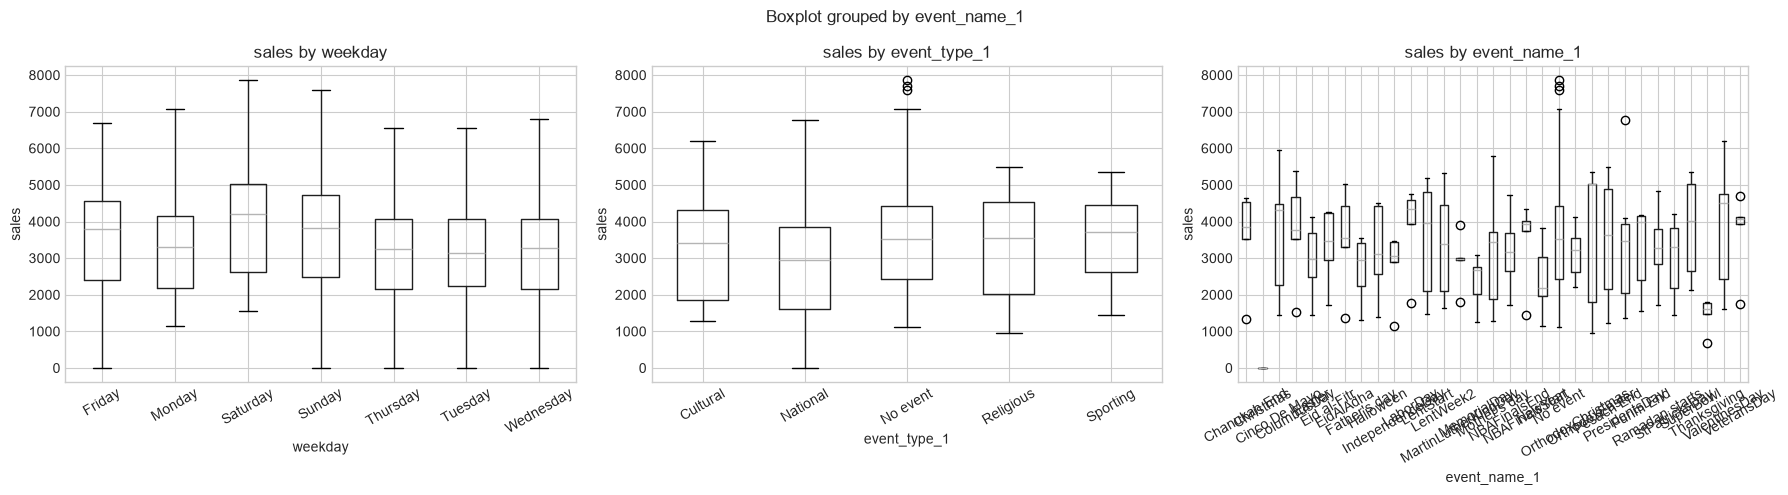

In [17]:
significant_categorical_features = kruskal_results.loc[
    kruskal_results["significant"],
    "feature",
].tolist()

if significant_categorical_features:
    fig, axes = plt.subplots(
        1,
        len(significant_categorical_features),
        figsize=(6 * len(significant_categorical_features), 5),
        squeeze=False,
    )

    for feature, axis in zip(
        significant_categorical_features,
        axes.flatten(),
    ):
        association_df = df[[feature, "sales"]].dropna()
        association_df.boxplot(column="sales", by=feature, ax=axis)
        axis.set_title(f"sales by {feature}")
        axis.set_xlabel(feature)
        axis.set_ylabel("sales")
        axis.tick_params(axis="x", rotation=90)

    plt.tight_layout()
    plt.show()

### Significant associations

The significant tests identify descriptive associations with daily sales. `snap_WI` has a moderate positive Spearman association with sales (rho = 0.392, p < 0.001). The Kruskal–Wallis results indicate significant differences in sales distributions across `weekday` (p < 0.001), `event_type_1` (p = 0.0066), and `event_name_1` (p = 0.0474). The corresponding boxplots show how sales vary across these groups. These results describe relationships in this dataset and should not be interpreted as causal effects.

The remaining categorical features, `event_name_2` (p = 0.1518) and `event_type_2` (p = 0.6471), are not statistically significant at the 0.05 level.

## 4. Additional Analyses

The following diagnostics use the complete aggregated daily history.

### Bimodal sales and regime-change analysis

Compare pre-2012, January-May 2012, and post-June-2012 sales levels with item coverage.

In [21]:
transition_summary = analysis_df[["sales", "d"]].copy()
transition_summary["nonzero_item_rows"] = transition_summary["d"].map(
    lambda day: (store_sales[day] > 0).sum()
)
transition_summary["period"] = pd.cut(
    transition_summary.index,
    [
        pd.Timestamp("2010-01-01"),
        pd.Timestamp("2012-01-01"),
        pd.Timestamp("2012-06-01"),
        pd.Timestamp("2016-07-01"),
    ],
    labels=["Before 2012", "Jan-May 2012", "From Jun 2012"],
)
transition_summary.groupby("period", observed=False)[
    ["sales", "nonzero_item_rows"]
].agg(["count", "mean", "median", "min", "max"]).round(2)

sales                              nonzero_item_rows           \
              count     mean  median   min   max             count     mean   
period                                                                        
Before 2012     338  1678.70  1651.5     3  2643               338   463.57   
Jan-May 2012    152  1884.02  1857.5  1140  3551               152   543.44   
From Jun 2012  1451  4027.72  3938.0     0  7852              1451  1039.10   

                                  
               median  min   max  
period                            
Before 2012     465.0    3   581  
Jan-May 2012    531.0  406   855  
From Jun 2012  1034.0    0  1585

The sales distribution is bimodal because the WI_2 series combines an early lower-sales regime with a later higher-sales regime. Before 2012, mean daily sales are 1,678.70 units with about 464 nonzero item rows per day. From June 2012 onward, mean daily sales increase to 4,027.72 units with about 1,039 nonzero item rows per day. This motivates treating the pre-June-2012 period as a separate regime and excluding it from modelling. The exact operational cause cannot be confirmed from the sales and calendar files alone.

### Autocorrelation analysis

Inspect autocorrelation plots and rank the 30 strongest non-zero lag correlations.

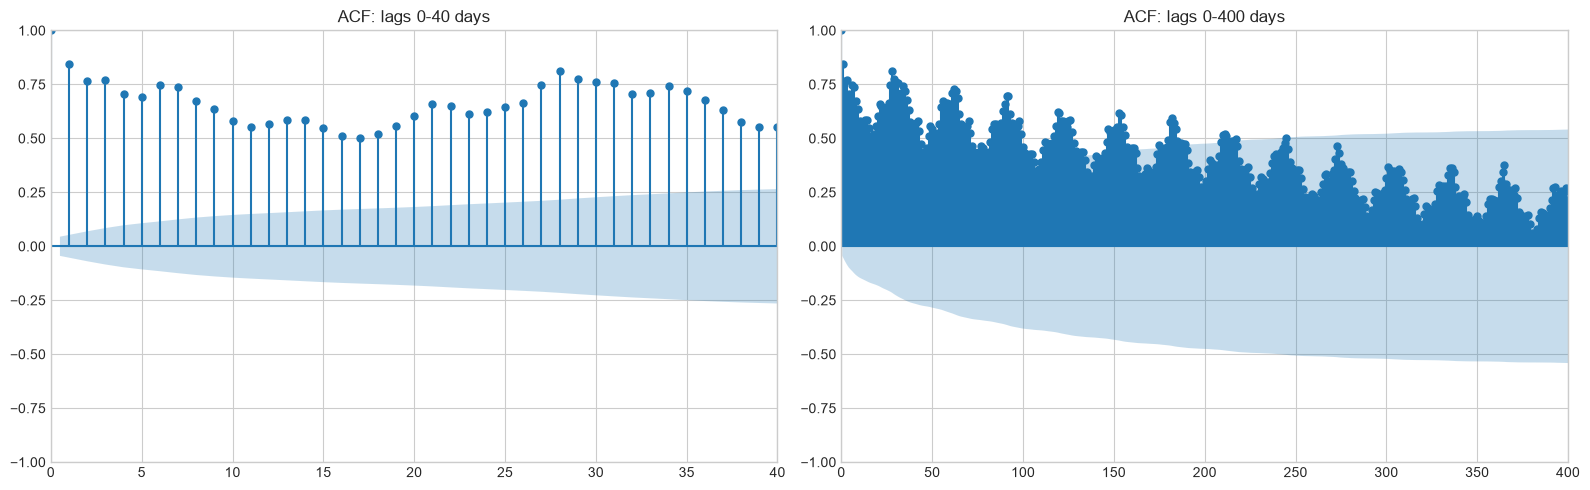

,lag_days,acf,abs_acf
0,1,0.8450,0.8450
1,28,0.8128,0.8128
2,29,0.7764,0.7764
3,3,0.7693,0.7693
4,2,0.7657,0.7657
5,30,0.7608,0.7608
6,31,0.7587,0.7587
7,6,0.7465,0.7465
8,27,0.7460,0.7460
9,34,0.7449,0.7449


In [22]:
from statsmodels.graphics.tsaplots import plot_acf

lag_ranges = [(0, 40), (0, 400)]
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for axis, (lag_start, lag_end) in zip(axes, lag_ranges):
    plot_acf(series, lags=400, ax=axis)
    axis.set_xlim(lag_start, lag_end)
    axis.set_title(f"ACF: lags {lag_start}-{lag_end} days")
plt.tight_layout()
plt.show()

#### Top ACF correlations

The table ranks the 30 non-zero lags with the strongest absolute autocorrelation. The signed `acf` value shows whether each relationship is positive or negative.

In [ ]:
# rank the strongest non-zero autocorrelations
from statsmodels.tsa.stattools import acf

acf_values = acf(series, nlags=400, fft=True)
top_acf_correlations = (
    pd.DataFrame({
        'lag_days': range(1, len(acf_values)),
        'acf': acf_values[1:],
    })
    .assign(abs_acf=lambda frame: frame['acf'].abs())
    .sort_values('abs_acf', ascending=False)
    .head(30)
    .reset_index(drop=True)
    .round(4)
)
top_acf_correlations


The ACF plots show dependence between current sales and previous sales values. The ranked lag table provides evidence that earlier sales values are related to current sales, with strong short-term and recurring longer-horizon correlations. These dependencies should be respected when constructing forecasting features and chronological validation.

### Seasonal decomposition

Decompose the daily sales series for 7-day, 28-day, and 365-day periods.

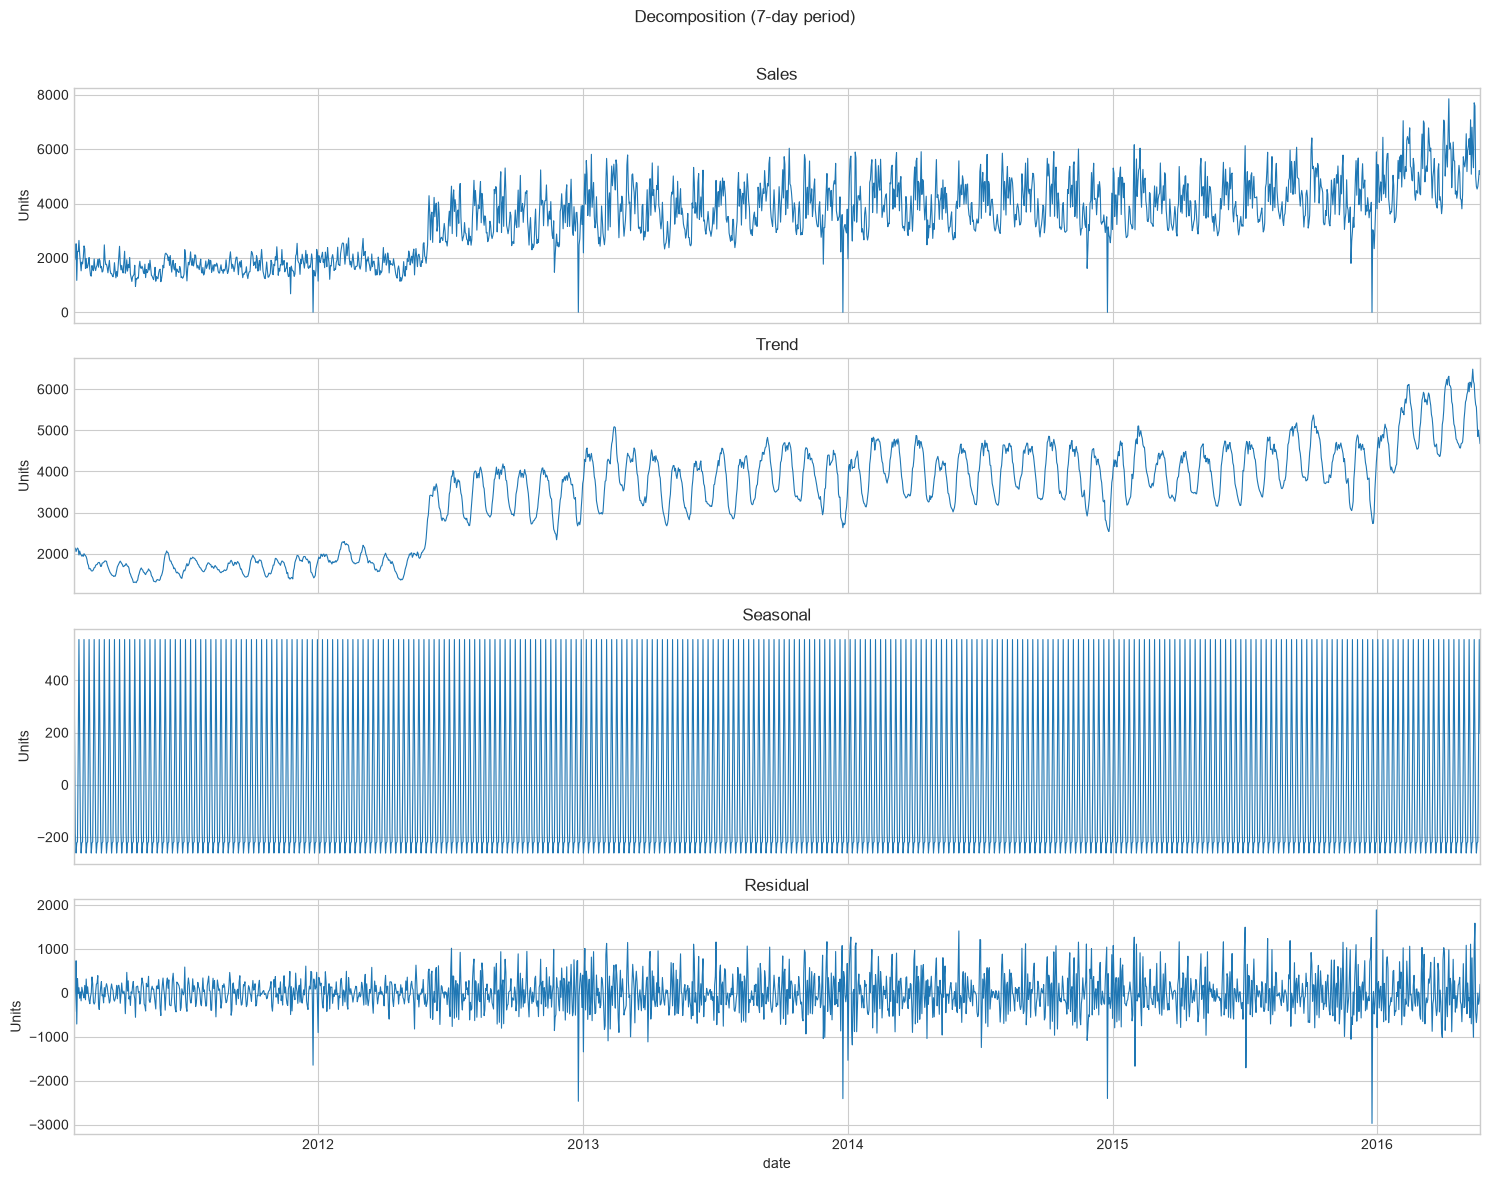

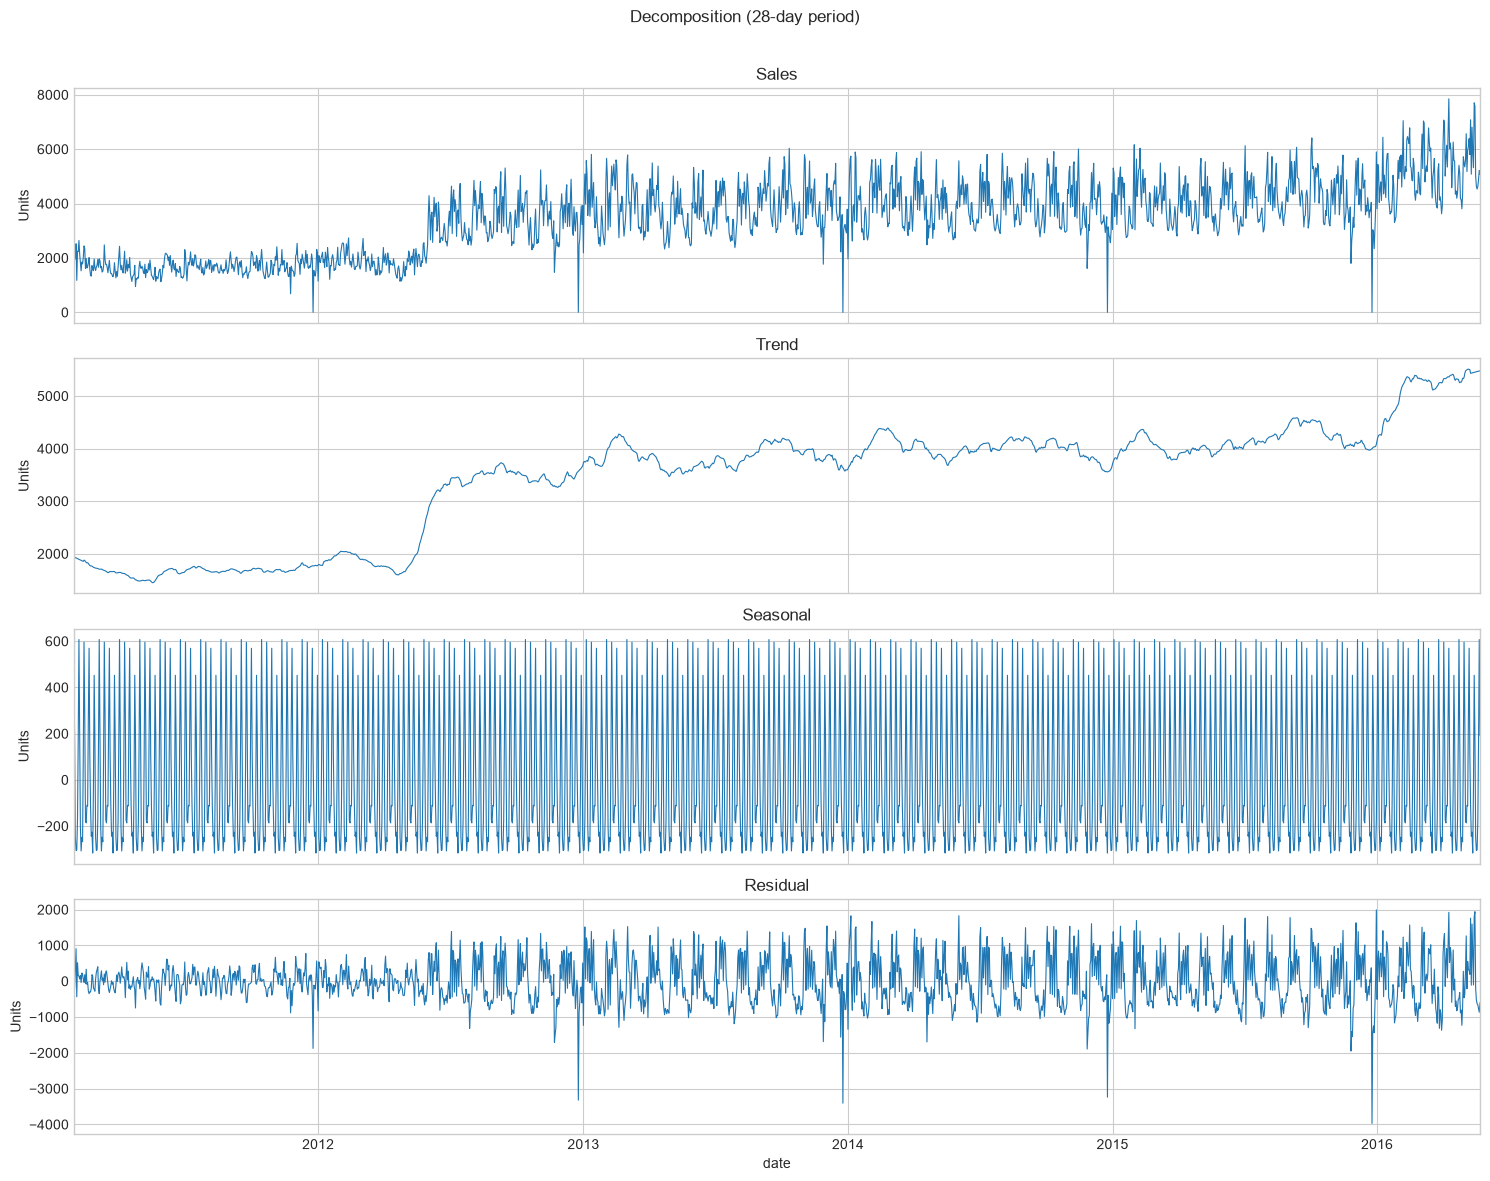

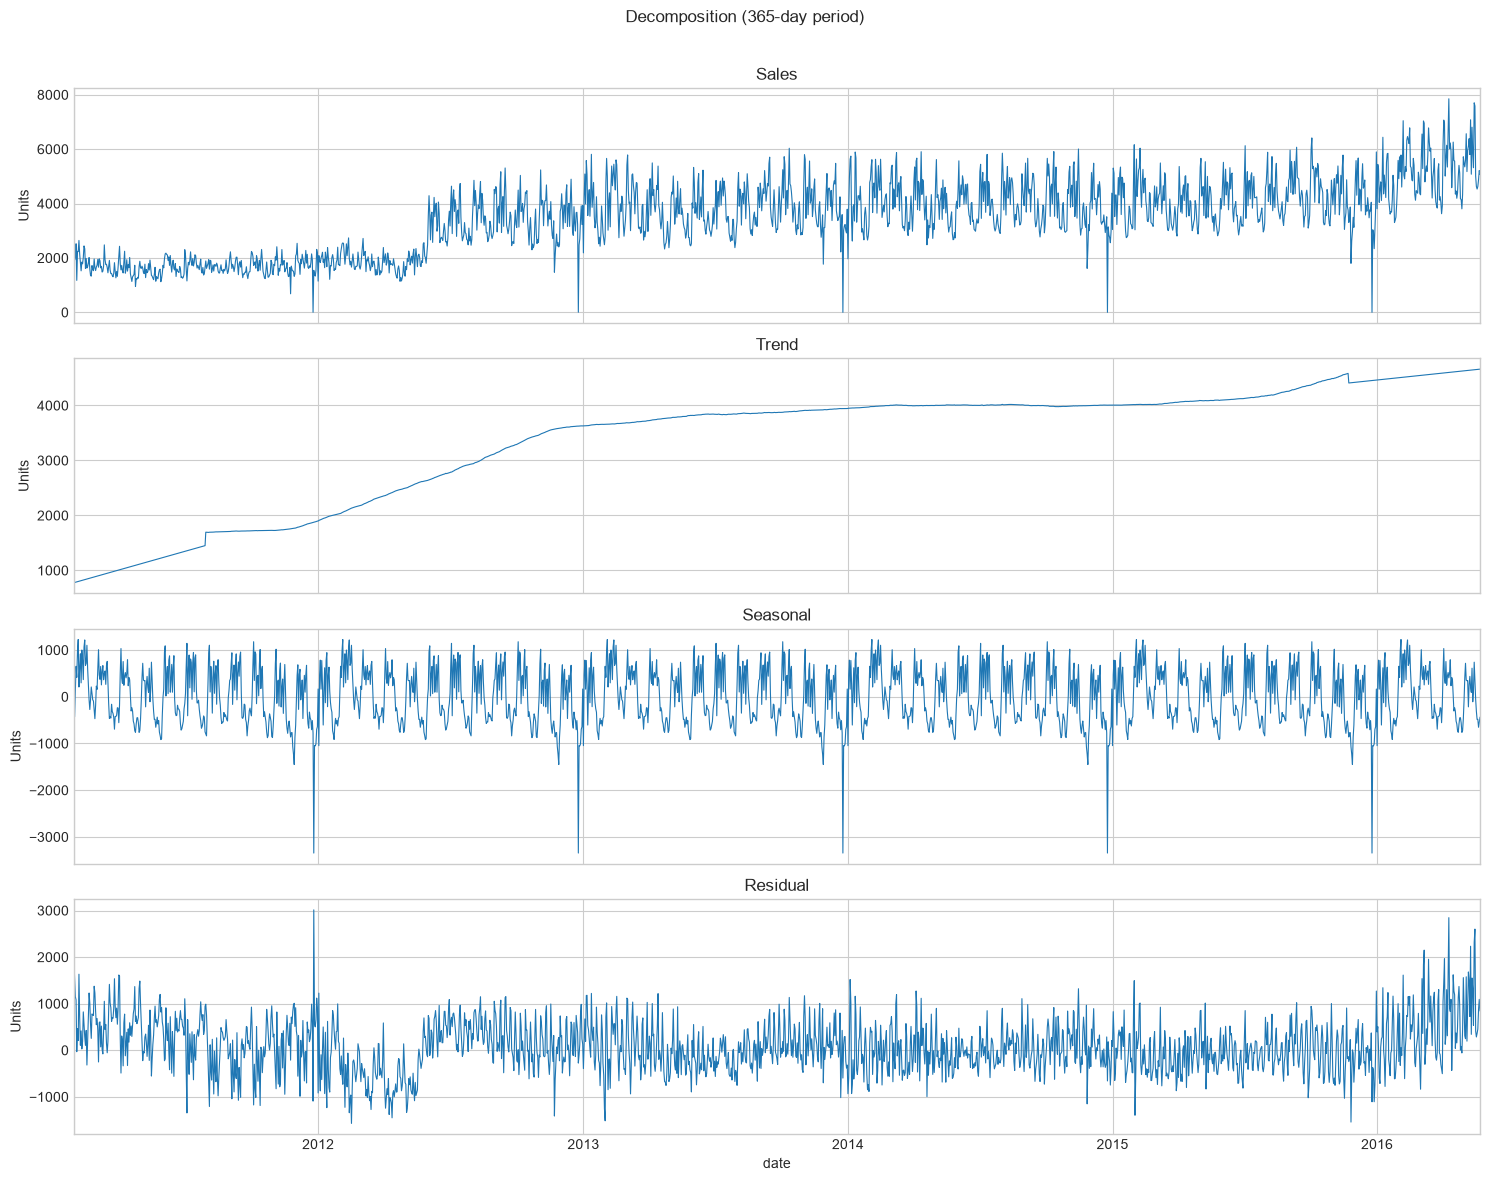

In [23]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition_periods = (7, 28, 365)
component_names = {
    "observed": "Sales",
    "trend": "Trend",
    "seasonal": "Seasonal",
    "resid": "Residual",
}

for period in decomposition_periods:
    decomposition = seasonal_decompose(
        series,
        model="additive",
        period=period,
        extrapolate_trend=period,
    )
    fig, axes = plt.subplots(
        len(component_names),
        1,
        figsize=(15, 12),
        sharex=True,
    )
    for axis, (component, title) in zip(axes, component_names.items()):
        getattr(decomposition, component).plot(ax=axis, linewidth=0.8)
        axis.set_title(title)
        axis.set_ylabel("Units")
        axis.grid(True)
    fig.suptitle(f"Decomposition ({period}-day period)")
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()

These separate decompositions make it easier to compare how the weekly, 28-day, and annual periods divide the sales series into trend, seasonal, and residual components.

### Augmented Dickey-Fuller stationarity test

Test the raw sales series and its first difference.

In [24]:
from statsmodels.tsa.stattools import adfuller

adf_results = []
for label, values in {
    "raw sales": series,
    "first difference": series.diff().dropna(),
}.items():
    statistic, p_value, _, _, critical_values, _ = adfuller(
        values,
        autolag="AIC",
    )
    adf_results.append({
        "series": label,
        "adf_statistic": statistic,
        "p_value": p_value,
        "critical_value_5pct": critical_values["5%"],
    })

adf_table = pd.DataFrame(adf_results).round(4)
adf_table

/var/folders/z5/t6prsb910p5cn4_p8358dl280000gq/T/ipykernel_14762/976129832.py:8: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  statistic, p_value, _, _, critical_values, _ = adfuller(
/var/folders/z5/t6prsb910p5cn4_p8358dl280000gq/T/ipykernel_14762/976129832.py:8: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  statistic, p_value, _, _, critical_values, _ = adfuller(


,series,adf_statistic,p_value,critical_value_5pct
0,raw sales,-0.9639,0.7662,-2.8631
1,first difference,-26.1336,0.0000,-2.8631


The raw-series ADF p-value is 0.7662, so the null hypothesis of a unit root is not rejected at the 5% level. The first difference has a p-value below 0.001, providing evidence that differencing improves stationarity.

### Ljung-Box serial-dependence test

Test whether autocorrelations up to weekly, monthly, quarterly, and yearly lags are jointly zero.

In [25]:
from statsmodels.stats.diagnostic import acorr_ljungbox

dependency_lags = {
    "week": 7,
    "month": 30,
    "quarter": 90,
    "year": 365,
}
ljung_box_table = acorr_ljungbox(
    series,
    lags=list(dependency_lags.values()),
    return_df=True,
)[['lb_stat', 'lb_pvalue']]
ljung_box_table.index = pd.Index(dependency_lags, name="period")
ljung_box_table.insert(0, "lag_days", list(dependency_lags.values()))
ljung_box_table.round(4)

,lag_days,lb_stat,lb_pvalue
period,,,
week,7,7728.9416,0.0
month,30,25675.1092,0.0
quarter,90,65592.9557,0.0
year,365,149920.5830,0.0


The Ljung-Box p-values are 0.0000 at the weekly, monthly, quarterly, and yearly lags. The null hypothesis of no serial dependence is rejected at each scale, so the series is not white noise.